# <b><font color='teal'>Homework 22</font></b>

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	f1_score,
	classification_report,
	precision_recall_curve,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


1. Обучите модель логистической регрессии на наборе данных Breast Cancer. Оцените модель с помощью показателей точности, precision, recall и F1-score. Постройте кривую Precision-Recall.

In [2]:
# В переменную df_breast_cancer запишите датасет BreastCancer
breast_cancer = load_breast_cancer(as_frame=True)
df_breast_cancer = breast_cancer.frame
display(df_breast_cancer)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [3]:
# В переменную X запишите все данные из компонента data датасета
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
X = breast_cancer.data


In [4]:
# В переменную y запишите компонент target датасета
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
y = breast_cancer.target


In [5]:
# В переменные X_train, X_test, y_train, y_test запишите обучающие и тестовые данные
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [6]:
# Инициализируйте модель логистической регрессии в переменную model_log_regr
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
model_log_regr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))


In [7]:
# Обучите модель на обучающих данных
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
model_log_regr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [8]:
# Сделайте прогнозы для тестового набора в переменные y_pred_log_regr
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
y_pred_log_regr = model_log_regr.predict(X_test)


In [9]:
# В переменную y_scores_log_regr запишите результат работы функции predict_proba
# (Синтаксис в файле "Метрики оценки модели" - п.2 - Precision-Recall)
y_scores_log_regr = model_log_regr.predict_proba(X_test)[:, 1]


In [10]:
# Выведите отчет о классификации и сделайте вывод о точности модели на основе метрик precision, recall, F1-score
# (Синтаксис в файле "Обучение с учителем" - п.2 - Логистическая регрессия)
accuracy_log_regr = accuracy_score(y_test, y_pred_log_regr)
precision_log_regr = precision_score(y_test, y_pred_log_regr)
recall_log_regr = recall_score(y_test, y_pred_log_regr)
f1_log_regr = f1_score(y_test, y_pred_log_regr)

print("Accuracy:", accuracy_log_regr)
print("Precision:", precision_log_regr)
print("Recall:", recall_log_regr)
print("F1-score:", f1_log_regr)
print()
print(classification_report(y_test, y_pred_log_regr))
print("Модель логистической регрессии показывает хорошие значения метрик precision, recall и F1-score на тестовой выборке.")


Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1-score: 0.9861111111111112

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Модель логистической регрессии показывает хорошие значения метрик precision, recall и F1-score на тестовой выборке.


In [11]:
# Рассчитайте кривую Precision-Recall в переменные precisions_log_regr, recalls_log_regr, thresholds_log_regr
# (Синтаксис в файле "Метрики оценки модели" - п.2 - Precision-Recall)
precisions_log_regr, recalls_log_regr, thresholds_log_regr = precision_recall_curve(y_test, y_scores_log_regr)


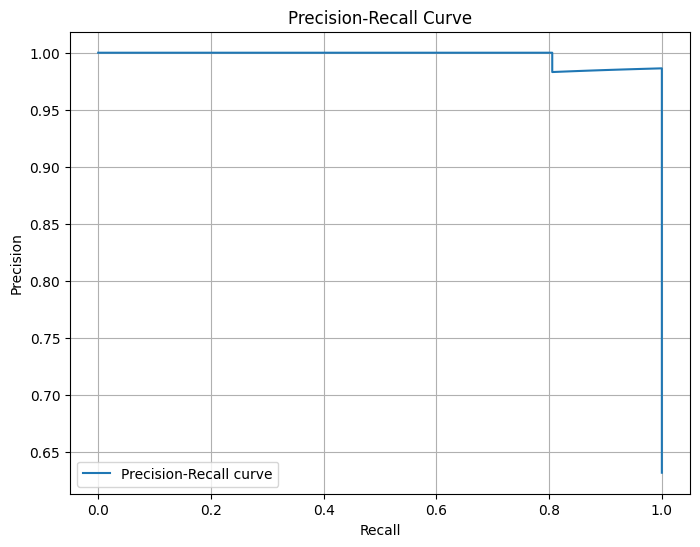

In [12]:
# Постройте график кривой Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recalls_log_regr, precisions_log_regr, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.legend()
plt.show()


2. Проведите кросс-валидацию с использованием набора данных banknote_authentication.csv и модели логистической регрессии. Оцените модель с помощью оценок кросс-валидации и постройте кривую обучения.

In [13]:
# Загрузите данные в датафрейм df_banknote
banknote_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt'
df_banknote = pd.read_csv(banknote_url, header=None, names=['A', 'B', 'C', 'D', 'target'])
display(df_banknote)


,A,B,C,D,target
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [14]:
# В переменную X запишите столбцы A, B, C, D
X = df_banknote[['A', 'B', 'C', 'D']]


In [15]:
# В переменную y запишите столбец target
y = df_banknote['target']


In [16]:
# Инициализируйте модель логистической регрессии в переменную model
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))


In [17]:
# Выполните перекрестную валидацию в переменную cv_scores
# (Синтаксис в файле "Переобучение и недообучение" - п.1.2. - Кросс-валидация)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')


In [18]:
# Выведите оценки кросс-валидации
print('Оценки кросс-валидации:', cv_scores)
print('Средняя accuracy:', cv_scores.mean())
print('Стандартное отклонение:', cv_scores.std())


Оценки кросс-валидации: [0.98545455 0.97818182 0.97080292 0.99270073 0.98175182]
Средняя accuracy: 0.9817783676177836
Стандартное отклонение: 0.007296692553297976


In [19]:
# Разделите данные на обучающий и тестовый наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [20]:
# Обучите модель на обучающих данных
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['A','B','C','D']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [21]:
# Сделайте предсказания на обучающем и тестовом наборах в переменные y_train_pred и y_test_pred
# (Синтаксис в файле "Переобучение и недообучение" - п.1.2. - Кросс-валидация)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [22]:
# Рассчитайте accuracy на обучающем и тестовом наборах в переменные train_accuracy и test_accuracy
# Выведите результаты на экран
# (Синтаксис в файле "Переобучение и недообучение" - п.1.2. - Кросс-валидация)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print('Train accuracy:', train_accuracy)
print('Test accuracy:', test_accuracy)


Train accuracy: 0.9845031905195989
Test accuracy: 0.9709090909090909


In [23]:
# Определите функцию для построения кривых обучения
# (Синтаксис в файле "Переобучение и недообучение" - п.1.1. - Кривые обучения)
def plot_learning_curve(estimator, X, y, title='Learning Curves', cv=5):
	from sklearn.model_selection import StratifiedKFold

	cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
	train_sizes, train_scores, valid_scores = learning_curve(
		estimator,
		X,
		y,
		cv=cv_strategy,
		scoring='accuracy',
		train_sizes=np.linspace(0.3, 1.0, 8),
		shuffle=True,
		n_jobs=-1,
		random_state=42
	)

	train_mean = train_scores.mean(axis=1)
	train_std = train_scores.std(axis=1)
	valid_mean = valid_scores.mean(axis=1)
	valid_std = valid_scores.std(axis=1)

	plt.figure(figsize=(10, 6))
	plt.title(title)
	plt.xlabel('Размер обучающей выборки')
	plt.ylabel('Accuracy')
	plt.grid(True)

	plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
	plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color='orange')
	plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train score')
	plt.plot(train_sizes, valid_mean, 'o-', color='orange', label='Validation score')
	plt.legend()
	plt.show()


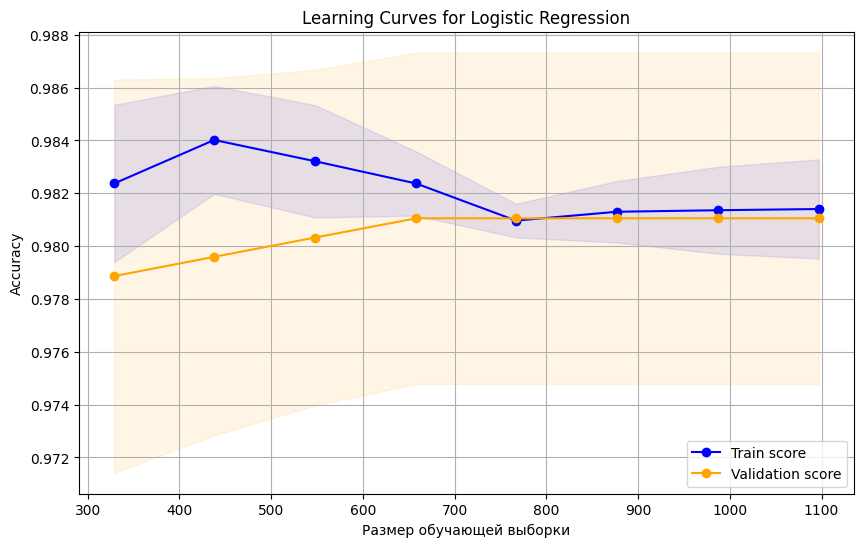

Если train accuracy заметно выше validation accuracy, модель склонна к переобучению.
Если обе кривые низкие и близкие друг к другу, это признак недообучения.


In [24]:
# Постройте кривые обучения и сделайте вывод о недообученности/переобученности модели
# (Синтаксис в файле "Переобучение и недообучение" - п.1.1. - Кривые обучения)
plot_learning_curve(model, X, y, title='Learning Curves for Logistic Regression')
print('Если train accuracy заметно выше validation accuracy, модель склонна к переобучению.')
print('Если обе кривые низкие и близкие друг к другу, это признак недообучения.')
